In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import sys
sys.path.append('/content/drive/MyDrive/my_library')
sys.path.append('/content/drive/MyDrive/Gastro/utils')

In [ ]:
import cv2
from dataloader import MultiClassDataset, dataframe, imfs2im # importing from utils
import torch
from torch import nn
from torch.utils.tensorboard import SummaryWriter
import numpy as np
from torchvision import datasets, transforms
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models
from datetime import datetime
from copy import deepcopy
import os
import matplotlib.pyplot as plt
import pandas as pd
import timm

### Parameters

In [ ]:
#%% Parameters
BASE_MODEL = 'efficientnet_b0'
BATCH_SIZE = 32
ONE_HOT = True
N_CLASSES = 8
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
LR = 0.001 #0.0001 # learning rate
EPOCHS = 50 #78 + 78
WEIGHT_DECAY = 1e-3 #1e-5
SAVE_WEIGHTS_ONLY = True
SAVE_BEST_MODEL = True
SAVE_LAST_MODEL = False
PERIOD = 20 # periodically save checkpoints
RAW_PREDICTION = False # if true, then stores raw predictions (i.e. before applying threshold)

PATIENCE = 30 # for early stopping
EARLY_STOP = False

RESIZE = (64, 64)
EMD_DICT = {
    "to_emd": True, # if True, then performs emd
    "subtract": True, # if True, then subtract IMF from original image
    "imf_index": [-1,-2,-3], # list of indices of desired imfs
    "to_gray": False, # if True, converts imfs to grayscale
    "normalize": True, # if True, normalizes the imfs
    }

In [ ]:
#%% Create model name
model_name = BASE_MODEL + '_emd' + str(EMD_DICT["to_emd"]) + '_subtract' + str(EMD_DICT["subtract"]) + 'IMF[-1-2-3]' + '_gray' + str(EMD_DICT["to_gray"]) + '_imsize' + str(RESIZE[0]) + '_' + datetime.now().strftime('%Y-%m-%d_%H-%M-%S')
print(model_name)

efficientnet_b0_emdTrue_subtractTrueIMF[-1-2-3]_grayFalse_imsize64_2025-12-02_16-08-31


In [ ]:
DEVICE

device(type='cuda')

### Dataloader

In [ ]:
root = '/content/drive/MyDrive/Gastro'
im_root = '/content/drive/MyDrive/Gastro/Dataset/kvasir-dataset-v2-cropped'

In [ ]:
train_transform = transforms.Compose([
    transforms.Resize(RESIZE),
    transforms.RandomHorizontalFlip(p=0.5),
])

val_transform = transforms.Compose([
    transforms.Resize(RESIZE),
    # transforms.ToTensor(),  # Convert images to tensors
])

test_transform = transforms.Compose([
    transforms.Resize(RESIZE),
    # transforms.ToTensor(),  # Convert images to tensors
])

In [ ]:
seed = np.random.seed(42)

df = dataframe(im_root, save_csv=False)

df_shuffled = df.sample(frac = 1, random_state=seed)

n_train_val = int(len(df_shuffled) * 0.60)
# n_test = int(len(df_shuffled) * 0.40)
n_train = int(n_train_val * 0.70)
n_val = int(n_train_val * 0.30)

# train_val_df = df_shuffled[0:200] # temp
train_val_df = df_shuffled[0:n_train_val]

# n_train = 100 # temp
train_df = train_val_df[0:n_train]
train_df = train_df.reset_index(drop=True) # reset indices starting from 0

val_df = train_val_df[n_train:]
val_df = val_df.reset_index(drop=True) # reset indices starting from 0

# test_df = df_shuffled[50:100] # temp
test_df = df_shuffled[n_train_val:]
test_df = test_df.reset_index(drop=True) # reset indices starting from 0

# Print
print('Total images:', int(len(df_shuffled)))
print('No. of training images:', n_train)
print('No. of validation images:', n_val)
print('No. of test images:', int(len(test_df)))

Total images: 8000
No. of training images: 3360
No. of validation images: 1440
No. of test images: 3200


In [ ]:
train_df.iloc[0,:]

,0
Image,/content/drive/MyDrive/Gastro/Dataset/kvasir-d...
Class,2


In [ ]:
train_df["Class"][0]

np.int64(2)

In [ ]:
DEFAULT_IMG_TRAIN = cv2.imread(os.path.join(train_df["Image"][0]))[:,:,::-1]
DEFAULT_MASK_TRAIN = train_df["Class"][0]

DEFAULT_IMG_VAL = cv2.imread(os.path.join(val_df["Image"][0]))[:,:,::-1]
DEFAULT_MASK_VAL = val_df["Class"][0]

In [ ]:
train_dataset = MultiClassDataset(train_df,
                                  n_classes=N_CLASSES,
                                  emd_dict = EMD_DICT,
                                  transform=train_transform,
                                  one_hot=ONE_HOT,
                                  array=None,
                                  mode='train',
                                  default_img=DEFAULT_IMG_TRAIN,
                                  default_mask=DEFAULT_MASK_TRAIN,
                                  )

val_dataset = MultiClassDataset(val_df,
                                  n_classes=N_CLASSES,
                                  emd_dict = EMD_DICT,
                                  transform=val_transform,
                                  one_hot=ONE_HOT,
                                  array=None,
                                  mode='val',
                                  default_img=DEFAULT_IMG_VAL,
                                  default_mask=DEFAULT_MASK_VAL,)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=1)

val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=1)


In [ ]:
# train_df

### Create checkpoint directory

In [ ]:
# Checkpoint directory
checkpoint_loc = os.path.join(root, 'checkpoints', model_name)

# Create checkpoint directory if does not exist
if not os.path.exists(checkpoint_loc): os.makedirs(checkpoint_loc)

### Model

In [ ]:
#%% Model

# # Change the last layer for our classification
# model = models.resnet18(pretrained=False)
# model.fc = nn.Linear(512, N_CLASSES, bias=True) # for ResNet18

# Change the last layer for our classification
# model = models.resnet152(pretrained=False)
# model.fc = nn.Linear(2048, N_CLASSES, bias=True) # for ResNet50 and 152

# # MobileNetV3_large
# model = models.mobilenet_v3_large(pretrained=False)
# model.classifier[3] = nn.Linear(1280, N_CLASSES, bias=True)

# VGG19BN
# model = models.vgg19_bn(pretrained=False)
# model.classifier[6] = nn.Linear(4096, N_CLASSES, bias=True)

# For Swin-v2-s
# model = models.swin_v2_s(pretrained=False)
# model.head = nn.Linear(in_features=768, out_features=N_CLASSES, bias=True)

# For efficientnet-b0
model = models.efficientnet_b0(pretrained=True)
model.classifier[1] = nn.Linear(model.classifier[1].in_features, N_CLASSES)

# For inception resnet-v2
# model = timm.create_model("inception_resnet_v2", pretrained=True)
# model.classif = nn.Linear(model.classif.in_features, N_CLASSES)

# For SEResNet50
# model = timm.create_model("seresnet50", pretrained=True)
# in_features = model.get_classifier().in_features   # timm helper
# model.fc = nn.Linear(in_features, N_CLASSES)

# model = model.to(DEVICE)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 147MB/s]


### Change the input layer to match with our input channels.

In [ ]:
# For ResNet
# model.conv1 = nn.Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False) # For ResNet

# For VGG19bn
# model.features[0] = nn.Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))

# For Swin-v2-s
# model.features[0][0] = nn.Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))

model.to(DEVICE)

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

### Optimizer, learning rate scheduler, and loss function

In [ ]:
# Optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

# Learning rate scheduler
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer,
                              factor=0.1,
                              mode='min',
                              patience=10,
                              min_lr=0.00001,
                              # verbose=True,
                              )

# Loss function
loss_fn = nn.CrossEntropyLoss()

### Helper function

In [ ]:
#%% Helper function: Save model
def save(model_path, epoch, model_state_dict, optimizer_state_dict):

    state = {
        'epoch': epoch + 1,
        'state_dict': deepcopy(model_state_dict),
        'optimizer': deepcopy(optimizer_state_dict),
        }

    torch.save(state, model_path)

### Uncomment to retrain

In [ ]:
# retrain_model_name = 'swin_v2_s_emdTrue_subtractTrueIMF[-1,-2,-3]_grayFalse_imsize64_2023-12-04_03-53-45'

# retrain_checkpoint_loc = '/content/drive/MyDrive/Gastro/checkpoints/' + retrain_model_name
# retrain_checkpoint = torch.load(os.path.join(retrain_checkpoint_loc, 'best_model.pth'))
# model.load_state_dict(retrain_checkpoint['state_dict'])
# optimizer.load_state_dict(retrain_checkpoint['optimizer'])

### Training

In [ ]:
# ============================================================================ #
# ============================= Train one epoch ============================== #
# ============================================================================ #

# Link: https://pytorch.org/tutorials/beginner/introyt/trainingyt.html

show_report = 50 # reports loss after every 'show_report' batches in an epoch

# def train_one_epoch(epoch_index, tb_writer):
def train_one_epoch(epoch_index):
    running_loss = 0.
    last_loss = 0.

    # Here, we use enumerate(training_loader) instead of
    # iter(training_loader) so that we can track the batch
    # index and do some intra-epoch reporting
    for i, (inputs, labels) in enumerate(train_loader):
        # Every data instance is an input + label pair

        # # Skip this iteration if this batch contains None
        if None in (inputs, labels):
          continue

        # Moving to GPU
        inputs = inputs.to(DEVICE)
        labels = labels.to(DEVICE)

        # Zero your gradients for every batch!
        optimizer.zero_grad()

        # Make predictions for this batch
        outputs = model(inputs)

        # Compute the loss and its gradients
        loss = loss_fn(outputs, labels)
        loss.backward()

        # Adjust learning weights
        optimizer.step()

        # Gather data and report
        running_loss += loss.item()

        '''
        if i % show_report == show_report-1:
            # For loss
            last_loss = running_loss / show_report # loss per batch
            # print('  batch {} loss: {}'.format(i + 1, last_loss))
            tb_x = epoch_index * len(train_loader) + i + 1
            tb_writer.add_scalar('Loss/train', last_loss, tb_x)
            running_loss = 0.
        '''
    last_loss = running_loss / (i + 1)

    return last_loss


# ============================================================================ #
# ============================== Train N epochs ============================== #
# ============================================================================ #

timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
# writer = SummaryWriter('runs/fashion_trainer_{}'.format(timestamp))
writer = SummaryWriter(os.path.join(root, 'runs', 'fashion_trainer_{}'.format(timestamp)))

best_vloss = 1_000_000.
save_model = False # initially it is False
cnt_patience = 0
initial_epoch = 0

store_train_loss, store_val_loss = [], []

for epoch in range(initial_epoch, EPOCHS):
    print('EPOCH {}:'.format(epoch + 1))

    # Training phase
    # Make sure gradient tracking is on, and do a pass over the data
    model.train()
    # avg_loss = train_one_epoch(epoch, writer)
    avg_loss = train_one_epoch(epoch) ############### turned off writer

    store_train_loss.append(avg_loss) # average loss is not a tensor

    # Validation phase
    # We don't need gradients on to do reporting
    model.eval()

    with torch.no_grad():
      running_vloss = 0.0

      for i, (vinputs, vlabels) in enumerate(val_loader):

          # Move to GPU
          vinputs = vinputs.to(DEVICE)
          vlabels = vlabels.to(DEVICE)

          voutputs = model(vinputs)
          vloss = loss_fn(voutputs, vlabels)
          running_vloss += vloss

    avg_vloss = running_vloss / (i + 1)
    print('LOSS train {} valid {}'.format(avg_loss, avg_vloss))

    store_val_loss.append(avg_vloss.data.cpu().numpy().tolist()) # avg_vloss is a tensor and in gpu

    '''
    # Log the running loss averaged per batch
    # for both training and validation
    writer.add_scalars('Training vs. Validation Loss',
                    { 'Training' : avg_loss, 'Validation' : avg_vloss },
                    epoch + 1)
    writer.flush()
    '''

    # Track best performance, and save the model's state
    if avg_vloss < best_vloss:
        best_vloss = avg_vloss
        print(f'Validation loss reduced. Saving the model at epoch: {epoch:04d}')
        cnt_patience = 0 # reset patience
        best_model_epoch = epoch
        save_model = True

    else: cnt_patience += 1

    # Learning rate scheduler
    scheduler.step(avg_vloss) # monitor validation loss

    # Save the model
    if save_model:
        save(os.path.join(checkpoint_loc, 'best_model' + '.pth'),
              epoch+1, model.state_dict(), optimizer.state_dict())
        save_model = False

    # Early stopping
    if EARLY_STOP and cnt_patience >= PATIENCE:
      print(f"Early stopping at epoch: {epoch:04d}")
      break

    # Periodic checkpoint save
    if not SAVE_BEST_MODEL:
      if (epoch+1) % PERIOD == 0:
        save(os.path.join(checkpoint_loc, f"cp-{epoch+1:04d}.pth"),
              epoch+1, model.state_dict(), optimizer.state_dict())
        print(f'Checkpoint saved for epoch {epoch:04d}')

    # epoch += 1

if not EARLY_STOP and SAVE_LAST_MODEL:
    print('Saving last model')
    save(os.path.join(checkpoint_loc, 'last_model' + '.pth'),
          epoch+1, model.state_dict(), optimizer.state_dict())

EPOCH 1:
LOSS train 0.8047349007356734 valid 0.480780690908432
Validation loss reduced. Saving the model at epoch: 0000
EPOCH 2:
LOSS train 0.42827339810984477 valid 0.364606112241745
Validation loss reduced. Saving the model at epoch: 0001
EPOCH 3:
LOSS train 0.28383139286722453 valid 0.33681821823120117
Validation loss reduced. Saving the model at epoch: 0002
EPOCH 4:
LOSS train 0.24210174062422343 valid 0.3121888041496277
Validation loss reduced. Saving the model at epoch: 0003
EPOCH 5:
LOSS train 0.1772191379751478 valid 0.3126494586467743
EPOCH 6:
LOSS train 0.1510287370532751 valid 0.27168992161750793
Validation loss reduced. Saving the model at epoch: 0005
EPOCH 7:
LOSS train 0.15940672775641793 valid 0.3371771275997162
EPOCH 8:
LOSS train 0.15100869277403467 valid 0.3511035442352295
EPOCH 9:
LOSS train 0.11102261886532817 valid 0.28465911746025085
EPOCH 10:
LOSS train 0.15545879213050717 valid 0.32453301548957825
EPOCH 11:
LOSS train 0.17247897545319227 valid 0.5545214414596558

In [ ]:
best_model_epoch

45

### Plots

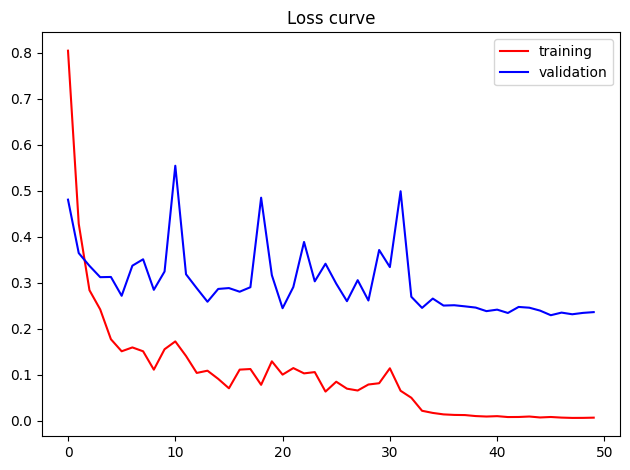

In [ ]:
plt.plot(store_train_loss, 'r')
plt.plot(store_val_loss, 'b')
plt.title("Loss curve")
plt.legend(['training', 'validation'])

plt.tight_layout()

save_fig_dir = os.path.join(root, "plots")
if not os.path.exists(save_fig_dir): os.makedirs(save_fig_dir)

plt.savefig(os.path.join(save_fig_dir, model_name + '.png'))

In [ ]:
# store_train_loss

## Inference

In [ ]:
len(test_df)

3200

In [ ]:
# # Test data loader
# test_dataset_dir = '/content/drive/MyDrive/Gastro/Dataset/test_dataset.npy'

# test_dataset_array = np.load(test_dataset_dir, allow_pickle=True)

In [ ]:
test_dataset = MultiClassDataset(test_df,
                                  n_classes=N_CLASSES,
                                  emd_dict = EMD_DICT,
                                  transform=test_transform,
                                  one_hot=ONE_HOT,
                                  array=None,
                                  mode='test',
                                 )

test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False, num_workers=1)

In [ ]:
# test_df

In [ ]:
# Test save directory
test_save_dir = os.path.join(root, "predictions")
os.makedirs(test_save_dir, exist_ok=True)

In [ ]:
# model_name = 'seresnet50_emdTrue_subtractTrueIMF[-1]_grayFalse_imsize64_2025-11-27_03-50-00'

checkpoint_loc = '/content/drive/MyDrive/Gastro/checkpoints/' + model_name
checkpoint = torch.load(os.path.join(checkpoint_loc, 'best_model.pth'))
model.load_state_dict(checkpoint['state_dict'])
optimizer.load_state_dict(checkpoint['optimizer'])

In [ ]:
from tqdm import tqdm

from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.metrics import roc_curve, RocCurveDisplay, auc
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_auc_score

model.eval()

true, pred, loc = [], [], []
with torch.no_grad():

  for i, (tinputs, tlabels, im_loc) in tqdm(enumerate(test_loader)):

      # Move to GPU
      tinputs = tinputs.to(DEVICE)
      tlabels = tlabels.to(DEVICE)

      # Prediction
      toutputs = model(tinputs)
      toutputs = torch.argmax(toutputs, dim=1)
      toutputs = toutputs.data.cpu().numpy().tolist()

      tlabels = torch.argmax(tlabels, dim=1)
      tlabels = tlabels.data.cpu().numpy().tolist()

      true.extend(tlabels)
      pred.extend(toutputs)
      loc.extend(im_loc)

      # print(im_loc)

df = pd.DataFrame(
            {
              "loc": loc,
             "true": true,
             "pred": pred,
             }
        )

df.to_excel(os.path.join(test_save_dir, model_name + ".xlsx"))


# ============ CM ======================
y_true = df["true"].tolist()
y_pred = df["pred"].tolist()

acc = accuracy_score(y_true, y_pred)
print('Accuracy:', acc*100)

cm = confusion_matrix(y_true, y_pred)

#---------------Generate confusion matrix---------------#
cr = classification_report(y_true, y_pred,
                           labels=[0, 1, 2, 3, 4, 5, 6, 7], output_dict=True)

df_cm = pd.DataFrame(cr).transpose() # convert confusion matrix to dataframe
print(df_cm)


3200it [29:31,  1.81it/s]


Accuracy: 94.09375
              precision    recall  f1-score      support
0              0.959569  0.890000  0.923476   400.000000
1              0.874384  0.917313  0.895334   387.000000
2              0.983133  0.987893  0.985507   413.000000
3              0.978155  0.985330  0.981730   409.000000
4              0.951407  0.961240  0.956298   387.000000
5              0.908854  0.861728  0.884664   405.000000
6              0.912195  0.968912  0.939698   386.000000
7              0.958637  0.953995  0.956311   413.000000
accuracy       0.940937  0.940937  0.940937     0.940937
macro avg      0.940792  0.940801  0.940377  3200.000000
weighted avg   0.941443  0.940937  0.940776  3200.000000


### Create confusion matrix and ROC

              precision    recall  f1-score      support
0              0.959569  0.890000  0.923476   400.000000
1              0.874384  0.917313  0.895334   387.000000
2              0.983133  0.987893  0.985507   413.000000
3              0.978155  0.985330  0.981730   409.000000
4              0.951407  0.961240  0.956298   387.000000
5              0.908854  0.861728  0.884664   405.000000
6              0.912195  0.968912  0.939698   386.000000
7              0.958637  0.953995  0.956311   413.000000
accuracy       0.940937  0.940937  0.940937     0.940937
macro avg      0.940792  0.940801  0.940377  3200.000000
weighted avg   0.941443  0.940937  0.940776  3200.000000


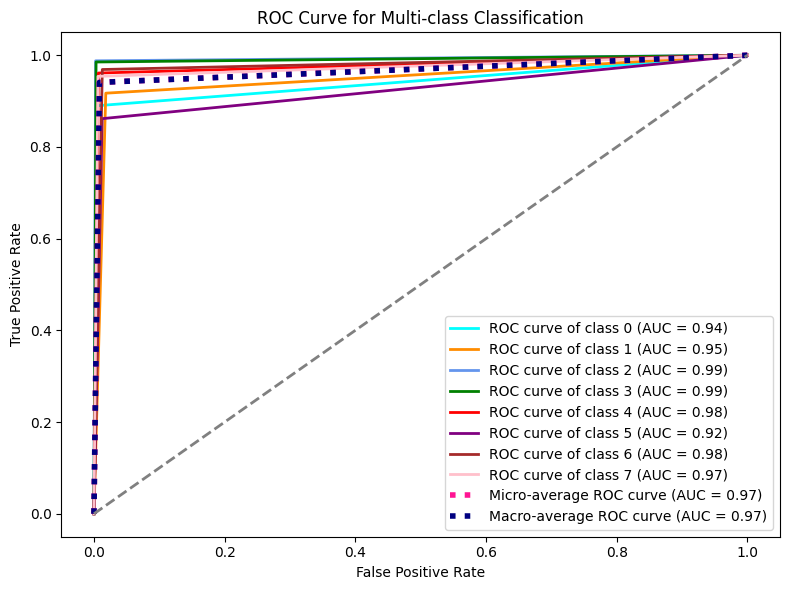

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import roc_curve, RocCurveDisplay, auc
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_auc_score

# model_name = 'resnet18_emdTrue123_imsize64_2023-07-24_00-12-31'
# file_name = model_name + '.xlsx'
# dir_xl = '/content/drive/MyDrive/Gastro/predictions/' + file_name
# df = pd.read_excel(dir_xl)

y_true = df["true"].tolist()
y_pred = df["pred"].tolist()

cm = confusion_matrix(y_true, y_pred)

#---------------Generate confusion matrix---------------#
cr = classification_report(y_true, y_pred,
                           labels=[0, 1, 2, 3, 4, 5, 6, 7], output_dict=True)

df_cm = pd.DataFrame(cr).transpose() # convert confusion matrix to dataframe
print(df_cm)

df_cm.to_excel(os.path.join(test_save_dir, model_name + "_conf_matrix" + ".xlsx"))

#---------------Generate ROC---------------#
# Note: This ROC is label-based, not usual predicted probability-based
# Step 1: Binarize the labels
n_classes = 8
y_true_bin = label_binarize(y_true, classes=np.arange(n_classes))
y_pred_bin = label_binarize(y_pred, classes=np.arange(n_classes))

# Step 2: Compute the ROC curve for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_pred_bin[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Step 3: Compute micro-average ROC curve
fpr_micro, tpr_micro, _ = roc_curve(y_true_bin.ravel(), y_pred_bin.ravel())
roc_auc_micro = auc(fpr_micro, tpr_micro)

# Step 4: Compute macro-average ROC curve
# Macro-average treats all classes equally, regardless of their frequency.
fpr_macro = np.mean(list(fpr.values()), axis=0)
tpr_macro = np.mean(list(tpr.values()), axis=0)
roc_auc_macro = auc(fpr_macro, tpr_macro)

# Step 5: Plot the ROC curves
plt.figure(figsize=(8, 6))
colors = ['aqua', 'darkorange', 'cornflowerblue', 'green', 'red', 'purple', 'brown', 'pink', 'yellow']

for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], color=colors[i], lw=2,
             label='ROC curve of class {0} (AUC = {1:0.2f})'.format(i, roc_auc[i]))

plt.plot(fpr_micro, tpr_micro, color='deeppink', linestyle=':', lw=4,
         label='Micro-average ROC curve (AUC = {0:0.2f})'.format(roc_auc_micro))

plt.plot(fpr_macro, tpr_macro, color='navy', linestyle=':', lw=4,
         label='Macro-average ROC curve (AUC = {0:0.2f})'.format(roc_auc_macro))

plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Multi-class Classification')
plt.legend(loc='lower right')
plt.tight_layout()

plt.savefig(os.path.join(test_save_dir, model_name + "_roc.png" ))

# plt.show()